Financial News Sentiment Analysis

Objective:
Investigate whether financial news sentiment can predict next-day market performance for SPY, DIA, and IWM.

1. Import Libraries

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Data together.xlsx to Data together.xlsx


2. Load Dataset
Dataset: Cleaned sentiment and market data exported from Excel.

In [6]:
import pandas as pd

df = pd.read_excel("Data together.xlsx", sheet_name="Raw data")
df.head()

,Day_of_week,signal_date,net_sentiment,mapped_trade_date,Holiday,Date,Close_DIA,Close_IWM,Close_SPY,High_DIA,...,DIA Daily Open to Close,SPY Daily Open to Close,IWM Daily Open to Close,DIA up or down,SPY up or down,IWM up or down,matched_DIA_result,matched_SPY_result,matched_IWM_result,sentiment_category
0,Sunday,2026-03-22,-2.0,2026-03-23,2026-04-03,2026-03-23,461.774017,247.449997,655.380005,466.841874,...,-0.002871,-0.004088,0.001133,DOWN,DOWN,UP,DOWN,DOWN,UP,Negative
1,Monday,2026-03-23,-2.0,2026-03-24,NaT,2026-03-24,460.974396,248.779999,653.179993,463.743210,...,0.005999,0.002856,0.013319,UP,UP,UP,UP,UP,UP,Negative
2,Tuesday,2026-03-24,0.0,2026-03-25,NaT,2026-03-25,463.943115,251.820007,656.820007,467.041776,...,-0.003414,-0.002809,0.000318,DOWN,DOWN,UP,DOWN,DOWN,UP,Neutral
3,Wednesday,2026-03-25,-5.0,2026-03-26,NaT,2026-03-26,459.115143,247.440002,645.090027,465.232542,...,-0.004832,-0.010689,-0.005826,DOWN,DOWN,DOWN,DOWN,DOWN,DOWN,Negative
4,Thursday,2026-03-26,-3.0,2026-03-27,NaT,2026-03-27,451.198547,243.100006,634.090027,457.305941,...,-0.013053,-0.013089,-0.011829,DOWN,DOWN,DOWN,DOWN,DOWN,DOWN,Negative


3. Data Preparation

Tasks completed:

Mapped sentiment dates to trading dates
Adjusted for weekends and holidays
Created binary UP/DOWN variables
Removed rows with missing market data

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df["SPY_binary"] = df["matched_SPY_result"].map({"UP":1, "DOWN":0})

df["DIA_binary"] = df["matched_DIA_result"].map({"UP":1, "DOWN":0})

df["IWM_binary"] = df["matched_IWM_result"].map({"UP":1, "DOWN":0})

In [ ]:
df = df.dropna(subset=["Close_SPY"])

4. Exploratory Data Analysis

Goal: Examine relationships between sentiment and market returns.

In [ ]:
print(df.groupby("sentiment_category")["SPY_binary"].mean())

print(df.groupby("sentiment_category")["DIA_binary"].mean())

print(df.groupby("sentiment_category")["IWM_binary"].mean())

sentiment_category
Negative    0.588235
Neutral     0.600000
Positive    0.000000
Name: SPY_binary, dtype: float64
sentiment_category
Negative    0.470588
Neutral     0.800000
Positive    1.000000
Name: DIA_binary, dtype: float64
sentiment_category
Negative    0.588235
Neutral     0.900000
Positive    1.000000
Name: IWM_binary, dtype: float64


In [ ]:
print(df.groupby("sentiment_category")["DIA Daily Open to Close"].mean())

sentiment_category
Negative    0.002913
Neutral    -0.002748
Positive         NaN
Name: DIA Daily Open to Close, dtype: float64


In [ ]:
print(df.groupby("sentiment_category")["SPY Daily Open to Close"].mean())

sentiment_category
Negative    0.002606
Neutral     0.000536
Positive         NaN
Name: SPY Daily Open to Close, dtype: float64


In [ ]:
print(df.groupby("sentiment_category")["IWM Daily Open to Close"].mean())

sentiment_category
Negative    0.005737
Neutral    -0.001412
Positive         NaN
Name: IWM Daily Open to Close, dtype: float64


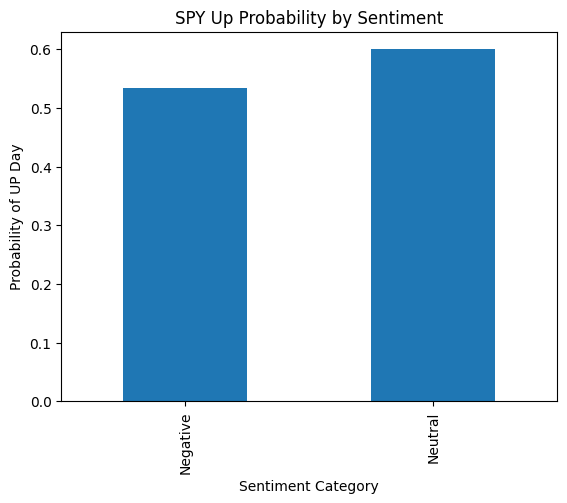

In [ ]:
import matplotlib.pyplot as plt

spy_means = df.groupby("sentiment_category")["SPY_binary"].mean()

spy_means.plot(kind="bar")

plt.title("SPY Up Probability by Sentiment")
plt.ylabel("Probability of UP Day")
plt.xlabel("Sentiment Category")

plt.show()

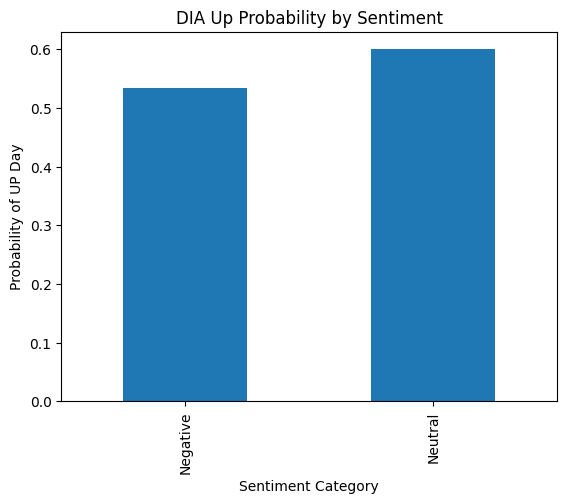

In [ ]:
import matplotlib.pyplot as plt

spy_means = df.groupby("sentiment_category")["DIA_binary"].mean()

spy_means.plot(kind="bar")

plt.title("DIA Up Probability by Sentiment")
plt.ylabel("Probability of UP Day")
plt.xlabel("Sentiment Category")

plt.show()

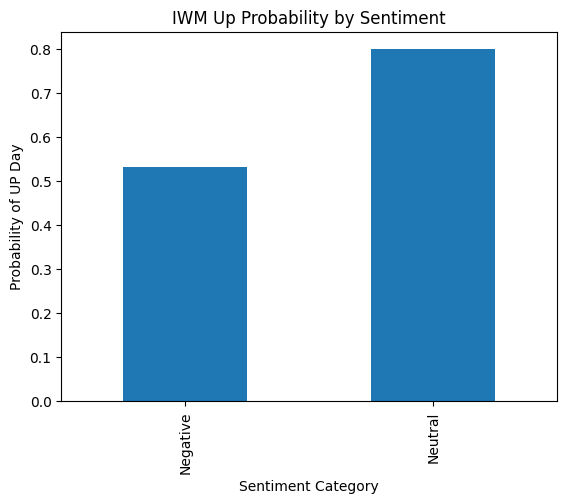

In [ ]:
import matplotlib.pyplot as plt

spy_means = df.groupby("sentiment_category")["IWM_binary"].mean()

spy_means.plot(kind="bar")

plt.title("IWM Up Probability by Sentiment")
plt.ylabel("Probability of UP Day")
plt.xlabel("Sentiment Category")

plt.show()

5. Logistic Regression Model

Goal: Test whether sentiment predicts next-day market direction.

Because the dataset contains only a small number of observations, the logistic regression results should be interpreted as exploratory rather than predictive.

In [ ]:
from sklearn.linear_model import LogisticRegression

X = df[["net_sentiment"]]
y = df["SPY_binary"]

model = LogisticRegression()

model.fit(X, y)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)
print("Accuracy:", model.score(X, y))

Coefficient: [[-0.0481085]]
Intercept: [0.08436585]
Accuracy: 0.55


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


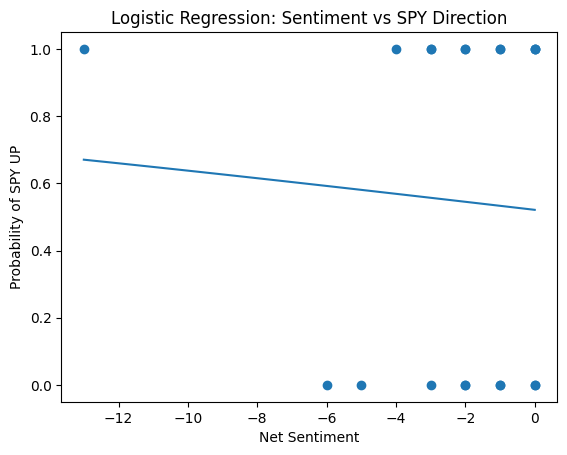

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot
plt.scatter(df["net_sentiment"], df["SPY_binary"])

# Generate smooth x values
x_vals = np.linspace(df["net_sentiment"].min(),
                     df["net_sentiment"].max(), 100)

# Logistic prediction probabilities
y_probs = model.predict_proba(x_vals.reshape(-1,1))[:,1]

# Plot logistic curve
plt.plot(x_vals, y_probs)

plt.title("Logistic Regression: Sentiment vs SPY Direction")

plt.xlabel("Net Sentiment")
plt.ylabel("Probability of SPY UP")

plt.show()

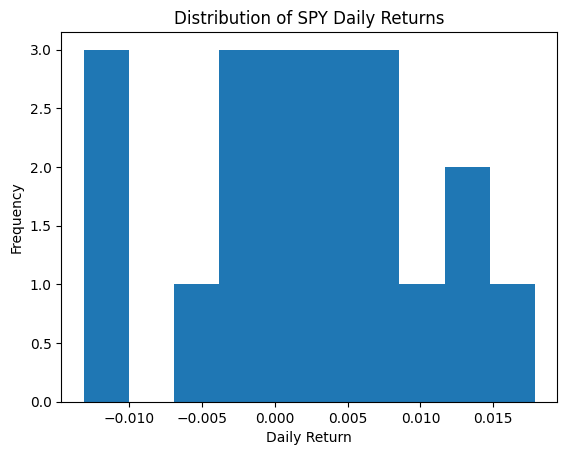

In [ ]:
plt.hist(df["SPY Daily Open to Close"])

plt.title("Distribution of SPY Daily Returns")

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

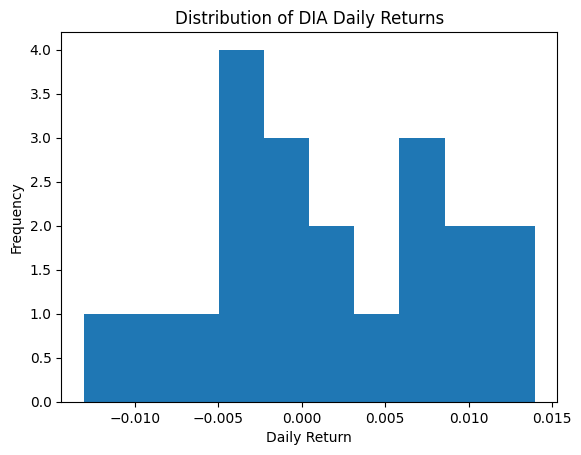

In [ ]:
plt.hist(df["DIA Daily Open to Close"])

plt.title("Distribution of DIA Daily Returns")

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

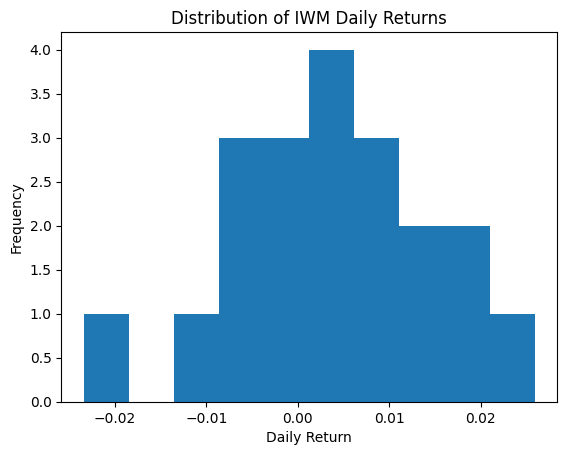

In [ ]:
plt.hist(df["IWM Daily Open to Close"])

plt.title("Distribution of IWM Daily Returns")

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

6. Conclusions

Key Findings

Negative sentiment did not consistently predict market declines.
Markets frequently rose despite negative news sentiment.
Logistic regression achieved approximately 55% accuracy.
Daily sentiment showed only weak predictive power.

Limitations

Small sample size (~20 trading days)
Only one news source
Many market drivers beyond sentiment

Future Improvements

Collect 6–12 months of sentiment data
Incorporate additional news sources
Test more advanced ML models

This project served as an introduction to financial data analysis, feature engineering, visualization, and machine learning using Python.